In [1]:
import os
import time
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import cumulative_trapezoid
import scipy.sparse as sp
import scipy.sparse.linalg as spla

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset


# =========================
def set_seed(seed=2026):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(2026)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)

device = cuda


In [3]:
# Part1 Define reaction coefficients, integral weights, and initial values.

def make_lam_fn(beta):
    """
    lambda(x)=50*cos(beta*arccos(x)).
    x should be in [0,1].
    """
    def lam(x):
        x = np.asarray(x)
        x_clip = np.clip(x, 0.0, 1.0)
        return 50.0 * np.cos(beta * np.arccos(x_clip))
    return lam


def get_simpson_coeff(spatial):
    """
    Simpson quadrature weights on [0,1].
    If the number of intervals is not even, use trapezoidal weights.
    """
    spatial = np.asarray(spatial, dtype=float)
    N = len(spatial)
    dx = spatial[1] - spatial[0]

    if (N - 1) % 2 != 0:
        w = np.ones(N) * dx
        w[0] *= 0.5
        w[-1] *= 0.5
        return w

    w = np.ones(N)
    w[1:-1:2] = 4.0
    w[2:-1:2] = 2.0
    w *= dx / 3.0
    return w


def make_initial_profile(spatial, init_type="sin", amp=10.0):
    """
    Initial state satisfying u(0)=u(1)=0.
    """
    spatial = np.asarray(spatial, dtype=float)

    if init_type == "sin":
        return amp * np.sin(np.pi * spatial)

    if init_type == "sin2":
        return amp * np.sin(2.0 * np.pi * spatial)

    if init_type == "mixed":
        return amp * (0.8 * np.sin(np.pi * spatial) + 0.2 * np.sin(2.0 * np.pi * spatial))

    raise ValueError("Unknown init_type.")

In [4]:
# Part2 Define functions to solve the controller kernel k(x,y) and observer kernel g(x,y) using Goursat marching in characteristic coordinates.
def solve_k(lambda_func, spatial, return_Kxy=False, check=False):
    """
    Solve the controller kernel k(x,y) on 0 <= y <= x <= 1.

    Kernel equation:
        k_xx(x,y) - k_yy(x,y) = lambda(y) k(x,y)

    Boundary conditions:
        k(x,0) = 0
        k(x,x) = -1/2 int_0^x lambda(s) ds

    Characteristic coordinates:
        r = x + y
        s = x - y
    """

    spatial = np.asarray(spatial, dtype=float)
    N = len(spatial)
    dx = spatial[1] - spatial[0]

    if not np.allclose(np.diff(spatial), dx):
        raise ValueError("spatial must be a uniform grid.")

    Ns = N
    Nr = 2 * N - 1

    s_grid = np.linspace(0.0, 1.0, Ns)
    r_grid = np.linspace(0.0, 2.0, Nr)
    h = s_grid[1] - s_grid[0]

    ii = np.arange(Nr)[:, None]
    jj = np.arange(Ns)[None, :]
    valid = (ii >= jj) & (ii <= (Nr - 1 - jj))

    Krs = np.full((Nr, Ns), np.nan, dtype=np.float64)

    # Boundary s=0: k(x,x)
    x_int = spatial
    lam_int = np.asarray(lambda_func(x_int), dtype=np.float64)

    F = -0.5 * cumulative_trapezoid(lam_int, x_int, initial=0.0)
    Krs[:, 0] = np.interp(r_grid / 2.0, x_int, F)

    # Boundary r=s: k(x,0)=0
    for j in range(Ns):
        Krs[j, j] = 0.0

    # Goursat marching
    for i in range(Nr - 1):
        for j in range(Ns - 1):

            if not (
                valid[i, j]
                and valid[i + 1, j]
                and valid[i, j + 1]
                and valid[i + 1, j + 1]
            ):
                continue

            if (
                np.isnan(Krs[i + 1, j])
                or np.isnan(Krs[i, j + 1])
                or np.isnan(Krs[i, j])
            ):
                continue

            r_c = 0.5 * (r_grid[i] + r_grid[i + 1])
            s_c = 0.5 * (s_grid[j] + s_grid[j + 1])
            y_c = 0.5 * (r_c - s_c)

            a_c = 0.25 * float(lambda_func(y_c))
            q = (h * h * a_c) / 4.0

            SW = Krs[i, j]
            SE = Krs[i + 1, j]
            NW = Krs[i, j + 1]

            # Semi-implicit midpoint update for NE
            # NE - SE - NW + SW = h^2 a_c * (SW+SE+NW+NE)/4
            denom = 1.0 - q
            NE = (SE + NW - SW + q * (SW + SE + NW)) / denom

            Krs[i + 1, j + 1] = NE

    # Extract k(1,y)
    r_index = np.arange(N - 1, 2 * N - 1)
    s_index = np.arange(N - 1, -1, -1)
    Kxy_gain = Krs[r_index, s_index].copy()

    Kxy = None
    if return_Kxy or check:
        Kxy = np.full((N, N), np.nan, dtype=np.float64)
        for i in range(N):
            for j in range(i + 1):
                r_idx = i + j
                s_idx = i - j
                Kxy[i, j] = Krs[r_idx, s_idx]

    if check:
        diag_err = np.nanmax(np.abs(np.diag(Kxy) - F))
        left_boundary_err = np.nanmax(np.abs(Kxy[:, 0]))

        print("solve_k consistency check:")
        print(f"  max diagonal error = {diag_err:.3e}")
        print(f"  max k(x,0) error   = {left_boundary_err:.3e}")

    if return_Kxy:
        return Krs, Kxy, Kxy_gain

    return Krs, Kxy_gain


def solve_g(lambda_func, spatial, check=False):
    """
    Directly solve the observer kernel g(x,y) on 0 <= y <= x <= 1.

    Observer kernel equation:
        g_xx(x,y) - g_yy(x,y) = -lambda(x) g(x,y)

    Boundary conditions:
        g(1,y) = 0
        g(x,x) = -1/2 int_x^1 lambda(s) ds

    Observer gain:
        g1(x) = -g(x,0)

    Return:
        Gxy     : lower-triangular array, Gxy[i,j]=g(x_i,y_j)
        g1_gain : array, g1_gain[i]=g1(x_i)
    """

    spatial = np.asarray(spatial, dtype=float)
    N = len(spatial)
    dx = spatial[1] - spatial[0]

    if not np.allclose(np.diff(spatial), dx):
        raise ValueError("spatial must be a uniform grid.")

    Ns = N
    Nr = 2 * N - 1

    s_grid = np.linspace(0.0, 1.0, Ns)
    r_grid = np.linspace(0.0, 2.0, Nr)
    h = s_grid[1] - s_grid[0]

    ii = np.arange(Nr)[:, None]
    jj = np.arange(Ns)[None, :]
    valid = (ii >= jj) & (ii <= (Nr - 1 - jj))

    Grs = np.full((Nr, Ns), np.nan, dtype=np.float64)

    # Boundary s=0: g(x,x) = -1/2 int_x^1 lambda(z) dz
    x_int = spatial
    lam_int = np.asarray(lambda_func(x_int), dtype=np.float64)

    F = cumulative_trapezoid(lam_int, x_int, initial=0.0)
    F_total = F[-1]

    x_on_r = r_grid / 2.0
    F_on_r = np.interp(x_on_r, x_int, F)

    Grs[:, 0] = -0.5 * (F_total - F_on_r)

    # Boundary x=1: r+s=2
    for j in range(Ns):
        i_right = Nr - 1 - j
        Grs[i_right, j] = 0.0

    # March from right to left
    for j in range(Ns - 1):

        i_right_next = Nr - 1 - (j + 1)

        for i in range(i_right_next - 1, j, -1):

            if not (
                valid[i, j]
                and valid[i + 1, j]
                and valid[i, j + 1]
                and valid[i + 1, j + 1]
            ):
                continue

            if (
                np.isnan(Grs[i + 1, j + 1])
                or np.isnan(Grs[i + 1, j])
                or np.isnan(Grs[i, j])
            ):
                continue

            r_c = 0.5 * (r_grid[i] + r_grid[i + 1])
            s_c = 0.5 * (s_grid[j] + s_grid[j + 1])
            x_c = 0.5 * (r_c + s_c)

            a_c = -0.25 * float(lambda_func(x_c))
            q = (h * h * a_c) / 4.0

            SW = Grs[i, j]
            SE = Grs[i + 1, j]
            NE = Grs[i + 1, j + 1]

            # Solve for NW:
            # NE - SE - NW + SW = h^2 a_c * (SW+SE+NW+NE)/4
            NW_tilde = NE - SE + SW
            NW = (NW_tilde - q * (SW + SE + NE)) / (1.0 + q)

            Grs[i, j + 1] = NW

    # Convert to g(x,y)
    Gxy = np.full((N, N), np.nan, dtype=np.float64)

    for i in range(N):
        for j in range(i + 1):
            r_idx = i + j
            s_idx = i - j
            Gxy[i, j] = Grs[r_idx, s_idx]

    # Observer gain
    g1_gain = -Gxy[:, 0].copy()

    if check:
        diag_target = -0.5 * (F_total - F)
        diag_err = np.nanmax(np.abs(np.diag(Gxy) - diag_target))
        right_err = np.nanmax(np.abs(Gxy[-1, :]))

        print("solve_g consistency check:")
        print(f"  max diagonal error = {diag_err:.3e}")
        print(f"  max g(1,y) error   = {right_err:.3e}")

    return Gxy, g1_gain

In [5]:
# Part3 Build Crank--Nicolson matrices for the interior nodes, and compute the left boundary flux using second-order finite difference.
def build_interior_CN_mats(spatial, dt, lam_profile):
    """
    Interior-node Crank--Nicolson matrices for
        v_t = v_xx + lambda(x) v.
    Boundary values are handled separately.
    """
    spatial = np.asarray(spatial, dtype=float)
    dx = spatial[1] - spatial[0]
    Nx = len(spatial)
    n_int = Nx - 2

    lam_int = lam_profile[1:-1]

    main = -2.0 / dx**2 + lam_int
    off = np.ones(n_int - 1) / dx**2

    A = sp.diags(
        [off, main, off],
        offsets=[-1, 0, 1],
        shape=(n_int, n_int),
        format="csr"
    )

    I = sp.eye(n_int, format="csr")

    M_minus = I - 0.5 * dt * A
    M_plus = I + 0.5 * dt * A

    return M_minus, M_plus


def left_flux_second_order(v, dx):
    """
    u_x(0,t) ≈ (-3u(0,t)+4u(dx,t)-u(2dx,t))/(2dx).
    """
    return (-3.0 * v[0] + 4.0 * v[1] - v[2]) / (2.0 * dx)



In [6]:
# Part4 Define a function to simulate the output-feedback trajectory using the backstepping controller and observer. 
# Define a function to simulate the open-loop response of the PDE with zero control input.

def simulate_outputfeedback_trajectory(
    lam_param,
    spatial,
    nt,
    dt,
    init_type="sin",
    amp=10.0,
    check_kernel=False
):
    """
    Generate one trajectory by the classical output-feedback backstepping law.

    Return:
        lam_profile : [Nx]
        p_seq       : [nt], p(t)=u_x(0,t)
        U_seq       : [nt]
        u           : [nt,Nx]
        uhat        : [nt,Nx]
    """

    spatial = np.asarray(spatial, dtype=float)
    Nx = len(spatial)
    dx = spatial[1] - spatial[0]

    lambda_func = make_lam_fn(lam_param)
    lam_profile = np.asarray(lambda_func(spatial), dtype=np.float64)

    # Controller kernel boundary gain k(1,y)
    _, k_gain = solve_k(lambda_func, spatial)
    k_gain = np.asarray(k_gain, dtype=np.float64).reshape(-1)

    # Observer gain g1(x)=-g(x,0)
    Gxy, g1_gain = solve_g(lambda_func, spatial, check=check_kernel)
    g1_gain = np.asarray(g1_gain, dtype=np.float64).reshape(-1)

    # Quadrature weights
    wq = get_simpson_coeff(spatial).astype(np.float64)

    # Algebraic boundary control:
    # U = sum_j w_j k_j uhat_j, with uhat_N = U.
    denom = 1.0 - wq[-1] * k_gain[-1]
    if abs(denom) < 1e-10:
        raise RuntimeError("The feedback denominator is too close to zero.")

    cU = (wq[1:-1] * k_gain[1:-1]) / denom

    # Interior CN matrices
    M_minus, M_plus = build_interior_CN_mats(spatial, dt, lam_profile)
    n_int = Nx - 2

    eR = np.zeros(n_int)
    eR[-1] = 1.0

    plant_solver = spla.factorized(M_minus.tocsc())

    # Observer solver with implicit U^{n+1}=cU@uhat^{n+1}
    M_obs = M_minus.tolil()
    M_obs[-1, :] -= (dt / (2.0 * dx**2)) * cU
    obs_solver = spla.factorized(M_obs.tocsc())

    u = np.zeros((nt, Nx), dtype=np.float64)
    uhat = np.zeros((nt, Nx), dtype=np.float64)
    U = np.zeros(nt, dtype=np.float64)
    p = np.zeros(nt, dtype=np.float64)
    phat = np.zeros(nt, dtype=np.float64)

    # Initial conditions
    u[0, :] = make_initial_profile(spatial, init_type=init_type, amp=amp)
    uhat[0, :] = 0.0

    u[0, 0] = 0.0
    uhat[0, 0] = 0.0

    U[0] = float(cU @ uhat[0, 1:-1])
    u[0, -1] = U[0]
    uhat[0, -1] = U[0]

    for n in range(nt - 1):
        u_int = u[n, 1:-1]
        uh_int = uhat[n, 1:-1]

        U_old = U[n]

        p[n] = left_flux_second_order(u[n, :], dx)
        phat[n] = left_flux_second_order(uhat[n, :], dx)

        innovation = p[n] - phat[n]

        # Observer update
        rhs_hat = (
            M_plus @ uh_int
            + (dt / (2.0 * dx**2)) * U_old * eR
            + dt * g1_gain[1:-1] * innovation
        )

        uh_new_int = obs_solver(rhs_hat)

        # New control
        U_new = float(cU @ uh_new_int)

        # Plant update
        rhs_u = (
            M_plus @ u_int
            + (dt / (2.0 * dx**2)) * (U_old + U_new) * eR
        )

        u_new_int = plant_solver(rhs_u)

        u[n + 1, 0] = 0.0
        u[n + 1, 1:-1] = u_new_int
        u[n + 1, -1] = U_new

        uhat[n + 1, 0] = 0.0
        uhat[n + 1, 1:-1] = uh_new_int
        uhat[n + 1, -1] = U_new

        U[n + 1] = U_new

    p[-1] = left_flux_second_order(u[-1, :], dx)
    phat[-1] = left_flux_second_order(uhat[-1, :], dx)

    return (
        lam_profile.astype(np.float32),
        p.astype(np.float32),
        U.astype(np.float32),
        u.astype(np.float32),
        uhat.astype(np.float32),
    )



def simulate_open_loop(
    lam_param,
    spatial,
    nt,
    dt,
    init_type="sin",
    amp=10.0,
):
    """
    Open-loop response of the reaction-diffusion PDE.

    PDE:
        u_t = u_xx + lambda(x) u

    Boundary conditions:
        u(0,t)=0,
        u(1,t)=0

    This corresponds to U(t)=0.
    """

    spatial = np.asarray(spatial, dtype=float)
    Nx = len(spatial)

    lambda_func = make_lam_fn(lam_param)
    lam_profile = np.asarray(lambda_func(spatial), dtype=np.float64)

    M_minus, M_plus = build_interior_CN_mats(spatial, dt, lam_profile)
    solver = spla.factorized(M_minus.tocsc())

    u = np.zeros((nt, Nx), dtype=np.float64)

    # Initial condition
    u[0, :] = make_initial_profile(spatial, init_type=init_type, amp=amp)

    # Enforce homogeneous Dirichlet boundaries
    u[0, 0] = 0.0
    u[0, -1] = 0.0

    for n in range(nt - 1):
        u_int = u[n, 1:-1]

        rhs = M_plus @ u_int

        u_new_int = solver(rhs)

        u[n + 1, 0] = 0.0
        u[n + 1, 1:-1] = u_new_int
        u[n + 1, -1] = 0.0

    time_grid = np.arange(nt) * dt

    return {
        "time": time_grid,
        "spatial": spatial,
        "lambda": lam_profile.astype(np.float32),
        "u": u.astype(np.float32),
        "U": np.zeros(nt, dtype=np.float32),
    }

In [ ]:
# Part5 A funtion for generating an output feedback dataset.
def build_outputfeedback_dataset(
    num_traj,
    spatial,
    nt,
    dt,
    beta_range=(4.0, 9.0),
    seed=2026,
    save_dir=".",
    prefix="outputfeedback_dataset",
    init_type="sin",
    amp=10.0,
    check_first=False
):
    """
    Build dataset:
        lam_profiles : [N_traj,Nx]
        u_x0_seqs    : [N_traj,nt]
        U_seqs       : [N_traj,nt]
        lam_params   : [N_traj]
    """

    rng = np.random.default_rng(seed)
    lam_params_all = rng.uniform(beta_range[0], beta_range[1], size=num_traj)

    lam_profiles = []
    p_list = []
    U_list = []
    lam_params_valid = []

    t0 = time.time()

    for i, beta in enumerate(lam_params_all):
        try:
            lam_profile, p_seq, U_seq, _, _ = simulate_outputfeedback_trajectory(
                lam_param=beta,
                spatial=spatial,
                nt=nt,
                dt=dt,
                init_type=init_type,
                amp=amp,
                check_kernel=(check_first and i == 0)
            )

            if (
                np.any(~np.isfinite(lam_profile))
                or np.any(~np.isfinite(p_seq))
                or np.any(~np.isfinite(U_seq))
                or np.max(np.abs(U_seq)) > 1e8
                or np.max(np.abs(p_seq)) > 1e8
            ):
                print(f"Skip trajectory {i}: invalid values, beta={beta:.4f}")
                continue

            lam_profiles.append(lam_profile)
            p_list.append(p_seq)
            U_list.append(U_seq)
            lam_params_valid.append(beta)

        except Exception as e:
            print(f"Skip trajectory {i}: beta={beta:.4f}, error={repr(e)}")
            continue

        if (i + 1) % 100 == 0:
            elapsed = time.time() - t0
            print(
                f"Generated {i+1}/{num_traj}, "
                f"valid={len(lam_profiles)}, "
                f"elapsed={elapsed/60:.1f} min"
            )

    lam_profiles = np.stack(lam_profiles, axis=0).astype(np.float32)
    p_seqs = np.stack(p_list, axis=0).astype(np.float32)
    U_seqs = np.stack(U_list, axis=0).astype(np.float32)
    lam_params_valid = np.array(lam_params_valid, dtype=np.float32)

    timestamp = time.strftime("%Y%m%d_%H%M%S")
    os.makedirs(save_dir, exist_ok=True)

    save_path = os.path.join(
        save_dir,
        f"{prefix}_{timestamp}.npz"
    )

    np.savez(
        save_path,
        spatial=spatial.astype(np.float32),
        dt=np.array(dt, dtype=np.float32),
        nt=np.array(nt, dtype=np.int32),
        beta_range=np.array(beta_range, dtype=np.float32),
        lam_params=lam_params_valid,
        lam_profiles=lam_profiles,
        u_x0_seqs=p_seqs,
        U_seqs=U_seqs,
    )

    print("Saved dataset to:", save_path)
    print("lam_profiles:", lam_profiles.shape)
    print("u_x0_seqs:", p_seqs.shape)
    print("U_seqs:", U_seqs.shape)

    return save_path, lam_profiles, p_seqs, U_seqs

In [ ]:
# Part6  Generate Output Feedback Dataset.
dx = 0.01
spatial = np.linspace(0.0, 1.0, int(round(1.0 / dx)) + 1, dtype=np.float32)

dt = 0.001
nt = 2000

# test_path, lam_profiles_test, p_test, U_test = build_outputfeedback_dataset(
#     num_traj=8000,
#     spatial=spatial,
#     nt=nt,
#     dt=dt,
#     beta_range=(4.0, 9.0),
#     seed=2026,
#     save_dir=".",
#     prefix="outputfeedback_dataset_test",
#     init_type="sin",
#     amp=10.0,
#     check_first=True
# )

In [8]:
# Part 7 DataLoader
class PDEControlDataset(Dataset):
    def __init__(self, lam_profiles, u_x0_seqs, U_seqs, stats=None):
        self.lam_profiles_raw = lam_profiles.astype(np.float32)
        self.u_x0_seqs_raw = u_x0_seqs.astype(np.float32)
        self.U_seqs_raw = U_seqs.astype(np.float32)

        if stats is None:
            stats = self.compute_stats(
                self.lam_profiles_raw,
                self.u_x0_seqs_raw,
                self.U_seqs_raw
            )

        self.stats = stats

        self.lam_profiles = (self.lam_profiles_raw - stats["lam_mean"]) / stats["lam_std"]
        self.u_x0_seqs = (self.u_x0_seqs_raw - stats["p_mean"]) / stats["p_std"]
        self.U_seqs = (self.U_seqs_raw - stats["U_mean"]) / stats["U_std"]

        self.lam_profiles = torch.from_numpy(self.lam_profiles.astype(np.float32))
        self.u_x0_seqs = torch.from_numpy(self.u_x0_seqs.astype(np.float32))
        self.U_seqs = torch.from_numpy(self.U_seqs.astype(np.float32))

    @staticmethod
    def compute_stats(lam_profiles, u_x0_seqs, U_seqs):
        eps = 1e-8
        return {
            "lam_mean": np.float32(lam_profiles.mean()),
            "lam_std": np.float32(lam_profiles.std() + eps),
            "p_mean": np.float32(u_x0_seqs.mean()),
            "p_std": np.float32(u_x0_seqs.std() + eps),
            "U_mean": np.float32(U_seqs.mean()),
            "U_std": np.float32(U_seqs.std() + eps),
        }

    def __len__(self):
        return self.lam_profiles.shape[0]

    def __getitem__(self, idx):
        return (
            self.lam_profiles[idx],
            self.u_x0_seqs[idx],
            self.U_seqs[idx],
        )


def make_loaders_from_npz(
    dataset_path,
    batch_size=64,
    val_ratio=0.2,
    seed=2026
):
    data = np.load(dataset_path)

    spatial = data["spatial"]
    dt = float(data["dt"])
    lam_profiles = data["lam_profiles"]
    u_x0_seqs = data["u_x0_seqs"]
    U_seqs = data["U_seqs"]

    n_total = lam_profiles.shape[0]
    n_val = int(round(val_ratio * n_total))
    n_train = n_total - n_val

    rng = np.random.default_rng(seed)
    indices = rng.permutation(n_total)

    train_indices = indices[:n_train]
    val_indices = indices[n_train:]

    # Compute normalization statistics from training subset
    stats = PDEControlDataset.compute_stats(
        lam_profiles[train_indices],
        u_x0_seqs[train_indices],
        U_seqs[train_indices],
    )

    dataset = PDEControlDataset(lam_profiles, u_x0_seqs, U_seqs, stats=stats)

    train_set = Subset(dataset, train_indices.tolist())
    val_set = Subset(dataset, val_indices.tolist())

    train_loader = DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_set,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    print("Loaded dataset:", dataset_path)
    print("Total samples:", n_total)
    print("Train samples:", n_train)
    print("Val samples:", n_val)
    print("spatial:", spatial.shape)
    print("dt:", dt)
    print("lam_profiles:", lam_profiles.shape)
    print("u_x0_seqs:", u_x0_seqs.shape)
    print("U_seqs:", U_seqs.shape)
    print("stats:", stats)

    return spatial, dt, train_loader, val_loader, train_set, val_set, stats

In [ ]:
# Part8 Load the dataset and create DataLoaders
test_path ="outputfeedback_dataset_test.npz"
dataset_path = test_path    

spatial, dt, train_loader, val_loader, train_set, val_set, stats = make_loaders_from_npz(
    dataset_path=dataset_path,
    batch_size=64,
    val_ratio=0.2,
    seed=2026
)

Loaded dataset: outputfeedback_dataset_test_20260509_184402.npz
Total samples: 8000
Train samples: 6400
Val samples: 1600
spatial: (101,)
dt: 0.0010000000474974513
lam_profiles: (8000, 101)
u_x0_seqs: (8000, 2000)
U_seqs: (8000, 2000)
stats: {'lam_mean': np.float32(0.44856954), 'lam_std': np.float32(35.541466), 'p_mean': np.float32(11.359404), 'p_std': np.float32(36.98979), 'U_mean': np.float32(-18.557924), 'U_std': np.float32(65.90968)}


In [10]:
# Part9 Define the DeepONet-based encoder and LSTM controller.
import os
os.environ["DDE_BACKEND"] = "pytorch"

import deepxde as dde
import torch
import torch.nn as nn
import numpy as np


class LambdaEncoder(nn.Module):
    """
    DeepXDE-based DeepONet encoder.

    Input:
        lam_profile: [B, Nx]

    Output:
        z_lambda: [B, emb_dim]

    The DeepONetCartesianProd maps
        lambda(x) -> a spatial feature on the fixed grid.
    Then an MLP compresses this spatial feature into z_lambda.
    """

    def __init__(
        self,
        spatial,
        emb_dim=32,
        feature_dim=128,
        branch_hidden=(256, 256),
        trunk_hidden=(128, 256),
        activation="relu",
        kernel="Glorot normal",
    ):
        super().__init__()

        spatial = np.asarray(spatial, dtype=np.float32)
        self.nx = len(spatial)

        self.register_buffer(
            "grid",
            torch.from_numpy(spatial.reshape(-1, 1)).float()
        )

        branch_layers = [self.nx, *branch_hidden, feature_dim]
        trunk_layers = [1, *trunk_hidden, feature_dim]

        self.deeponet = dde.nn.DeepONetCartesianProd(
            branch_layers,
            trunk_layers,
            activation,
            kernel,
        )

        self.embed = nn.Sequential(
            nn.Linear(self.nx, 128),
            nn.ReLU(),
            nn.Linear(128, emb_dim),
            nn.ReLU(),
        )

    def forward(self, lam_profile):
        """
        lam_profile: [B, Nx]
        """

        # DeepXDE DeepONetCartesianProd input format:
        #   (branch_input, trunk_input)
        #
        # branch_input: [B, Nx]
        # trunk_input : [Nx, 1]
        spatial_feature = self.deeponet((lam_profile, self.grid))

        # Usually spatial_feature has shape [B, Nx].
        # This line is added for safety in case DeepXDE returns [B, Nx, 1].
        if spatial_feature.dim() == 3 and spatial_feature.shape[-1] == 1:
            spatial_feature = spatial_feature.squeeze(-1)

        z_lambda = self.embed(spatial_feature)

        return z_lambda


class LambdaLSTMController(nn.Module):
    """
    Hybrid DeepONet-LSTM controller.

    Input:
        lam_profile: [B, Nx]
        p_seq      : [B, T], where p(t)=u_x(0,t)

    Output:
        U_seq      : [B, T]
    """

    def __init__(
        self,
        spatial,
        emb_dim=32,
        lstm_hidden=64,
        num_layers=1,
        feature_dim=128,
        branch_hidden=(256, 256),
        trunk_hidden=(128, 256),
        activation="relu",
        kernel="Glorot normal",
    ):
        super().__init__()

        self.lambda_encoder = LambdaEncoder(
            spatial=spatial,
            emb_dim=emb_dim,
            feature_dim=feature_dim,
            branch_hidden=branch_hidden,
            trunk_hidden=trunk_hidden,
            activation=activation,
            kernel=kernel,
        )

        self.lstm = nn.LSTM(
            input_size=emb_dim + 1,
            hidden_size=lstm_hidden,
            num_layers=num_layers,
            batch_first=True,
        )

        self.head = nn.Sequential(
            nn.Linear(lstm_hidden, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, lam_profile, p_seq):
        """
        lam_profile: [B, Nx]
        p_seq      : [B, T]
        """

        B, T = p_seq.shape

        z_lambda = self.lambda_encoder(lam_profile)       # [B, emb_dim]
        z_seq = z_lambda.unsqueeze(1).repeat(1, T, 1)     # [B, T, emb_dim]

        p_seq = p_seq.unsqueeze(-1)                       # [B, T, 1]

        lstm_input = torch.cat([z_seq, p_seq], dim=-1)    # [B, T, emb_dim+1]

        lstm_out, _ = self.lstm(lstm_input)

        U_seq = self.head(lstm_out).squeeze(-1)           # [B, T]

        return U_seq

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [11]:
# Part10 Train the LambdaLSTMController on the output feedback dataset.
def train_controller_clean(
    spatial,
    train_loader,
    val_loader,
    stats,
    num_epochs=1000,
    emb_dim=32,
    hidden_size=64,
    num_layers=1,
    feature_dim=128,
    lr=2e-3,
    weight_decay=0.0,
    save_dir=".",
    save_prefix="lambda_lstm_controller_outputfeedback",
):
    model = LambdaLSTMController(
    spatial=spatial,
    emb_dim=emb_dim,
    lstm_hidden=hidden_size,
    num_layers=num_layers,
    feature_dim=feature_dim,
    branch_hidden=(256, 256),
    trunk_hidden=(128, 256),
    activation="relu",
    kernel="Glorot normal",
).to(device)

    criterion = nn.MSELoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=20,
        threshold=1e-3,
        threshold_mode="rel"
    )

    train_hist = []
    val_hist = []

    best_val_loss = float("inf")
    best_state = None

    timestamp = time.strftime("%Y%m%d_%H%M%S")
    os.makedirs(save_dir, exist_ok=True)

    best_model_path = os.path.join(
        save_dir,
        f"{save_prefix}_{timestamp}.pth"
    )

    history_path = os.path.join(
        save_dir,
        f"{save_prefix}_{timestamp}_history.npz"
    )

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for lam_batch, p_batch, U_batch in train_loader:
            lam_batch = lam_batch.to(device).float()
            p_batch = p_batch.to(device).float()
            U_batch = U_batch.to(device).float()

            optimizer.zero_grad()

            U_pred = model(lam_batch, p_batch)
            loss = criterion(U_pred, U_batch)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * lam_batch.size(0)

        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for lam_batch, p_batch, U_batch in val_loader:
                lam_batch = lam_batch.to(device).float()
                p_batch = p_batch.to(device).float()
                U_batch = U_batch.to(device).float()

                U_pred = model(lam_batch, p_batch)
                loss = criterion(U_pred, U_batch)

                val_loss += loss.item() * lam_batch.size(0)

        val_loss /= len(val_loader.dataset)

        scheduler.step(val_loss)

        train_hist.append(train_loss)
        val_hist.append(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:04d}/{num_epochs} | "
            f"train={train_loss:.4e} | "
            f"val={val_loss:.4e} | "
            f"lr={current_lr:.3e}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

            checkpoint = {
                "state_dict": best_state,
                "spatial": np.asarray(spatial, dtype=np.float32),
                "stats": stats,
                "config": {
                    "emb_dim": emb_dim,
                    "hidden_size": hidden_size,
                    "num_layers": num_layers,
                    "feature_dim": feature_dim,
                },
                "best_val_loss": best_val_loss,
            }

            torch.save(checkpoint, best_model_path)

        if current_lr < 1e-6:
            print("Learning rate is too small. Stop training.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    np.savez(
        history_path,
        train_hist=np.array(train_hist),
        val_hist=np.array(val_hist),
        best_val_loss=np.array(best_val_loss),
        best_model_path=np.array(best_model_path),
    )

    print("Best val loss:", best_val_loss)
    print("Best model saved to:", best_model_path)
    print("History saved to:", history_path)

    return model, train_hist, val_hist, best_model_path

In [12]:

torch.set_default_device("cpu")

spatial, dt, train_loader, val_loader, train_set, val_set, stats = make_loaders_from_npz(
    dataset_path=dataset_path,
    batch_size=64,
    val_ratio=0.2,
    seed=2026
)

Loaded dataset: outputfeedback_dataset_test_20260509_184402.npz
Total samples: 8000
Train samples: 6400
Val samples: 1600
spatial: (101,)
dt: 0.0010000000474974513
lam_profiles: (8000, 101)
u_x0_seqs: (8000, 2000)
U_seqs: (8000, 2000)
stats: {'lam_mean': np.float32(0.44856954), 'lam_std': np.float32(35.541466), 'p_mean': np.float32(11.359404), 'p_std': np.float32(36.98979), 'U_mean': np.float32(-18.557924), 'U_std': np.float32(65.90968)}


In [ ]:
# Part10 Run the training
model, train_hist, val_hist, best_model_path = train_controller_clean(
    spatial=spatial,
    train_loader=train_loader,
    val_loader=val_loader,
    stats=stats,
    num_epochs=1000,
    emb_dim=32,
    hidden_size=64,
    num_layers=1,
    feature_dim=128,
    lr=2e-3,
    save_dir=".",
    save_prefix="lambda_lstm_controller_outputfeedback",
)

Epoch 0001/1000 | train=1.6795e-01 | val=1.2941e-02 | lr=2.000e-03
Epoch 0002/1000 | train=7.7165e-03 | val=2.0957e-03 | lr=2.000e-03
Epoch 0003/1000 | train=2.3435e-03 | val=1.3768e-03 | lr=2.000e-03
Epoch 0004/1000 | train=1.1489e-03 | val=5.9857e-04 | lr=2.000e-03
Epoch 0005/1000 | train=5.9392e-04 | val=8.2353e-04 | lr=2.000e-03
Epoch 0006/1000 | train=1.1466e-03 | val=1.4344e-03 | lr=2.000e-03
Epoch 0007/1000 | train=4.9334e-03 | val=7.5842e-04 | lr=2.000e-03
Epoch 0008/1000 | train=6.6071e-04 | val=1.6636e-03 | lr=2.000e-03
Epoch 0009/1000 | train=6.2848e-04 | val=3.4044e-04 | lr=2.000e-03
Epoch 0010/1000 | train=2.9470e-04 | val=1.9807e-04 | lr=2.000e-03
Epoch 0011/1000 | train=2.5589e-04 | val=1.9329e-04 | lr=2.000e-03
Epoch 0012/1000 | train=2.5328e-04 | val=4.8118e-04 | lr=2.000e-03
Epoch 0013/1000 | train=1.4769e-03 | val=6.3718e-04 | lr=2.000e-03
Epoch 0014/1000 | train=2.7727e-04 | val=2.7804e-04 | lr=2.000e-03
Epoch 0015/1000 | train=4.6314e-04 | val=3.2554e-04 | lr=2.000

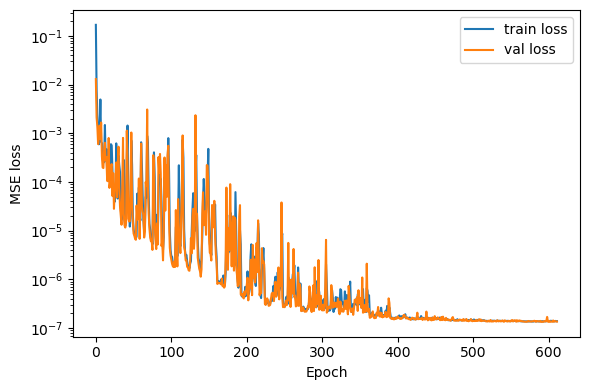

In [ ]:
# Part11 Plot the training history
plt.figure(figsize=(6, 4))
plt.semilogy(train_hist, label="train loss")
plt.semilogy(val_hist, label="val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# Some Denormalization Functions and
def denormalize_U(U_norm, stats):
    return U_norm * stats["U_std"] + stats["U_mean"]


def denormalize_p(p_norm, stats):
    return p_norm * stats["p_std"] + stats["p_mean"]


def denormalize_lam(lam_norm, stats):
    return lam_norm * stats["lam_std"] + stats["lam_mean"]


In [99]:
@torch.no_grad()
def predict_U_by_network(model, spatial_model, stats, spatial_cur, lam_profile_cur, p_seq):
    """
    Predict U_N(t) from lambda(x) and p(t)=u_x(0,t).

    If spatial_cur differs from spatial_model, lambda is interpolated.
    """

    model.eval()

    lam_on_model_grid = np.interp(
        spatial_model,
        spatial_cur,
        lam_profile_cur
    ).astype(np.float32)

    lam_norm = (lam_on_model_grid - stats["lam_mean"]) / stats["lam_std"]
    p_norm = (p_seq.astype(np.float32) - stats["p_mean"]) / stats["p_std"]

    lam_tensor = torch.from_numpy(lam_norm).unsqueeze(0).to(device).float()
    p_tensor = torch.from_numpy(p_norm).unsqueeze(0).to(device).float()

    U_pred_norm = model(lam_tensor, p_tensor)
    U_pred_norm = U_pred_norm.squeeze(0).cpu().numpy()

    U_pred = denormalize_U(U_pred_norm, stats)

    return U_pred

In [18]:
beta_test = 6

lam_profile, p_seq, U_seq, u_seq, uhat_seq = simulate_outputfeedback_trajectory(
    lam_param=beta_test,
    spatial=spatial,
    nt=nt,
    dt=dt,
    init_type="sin",
    amp=10.0,
    check_kernel=False
)

U_nn = predict_U_by_network(
    model=model,
    spatial_model=spatial,
    stats=stats,
    spatial_cur=spatial,
    lam_profile_cur=lam_profile,
    p_seq=p_seq
)

t = np.arange(nt) * dt

plt.figure(figsize=(6, 4))
plt.plot(t, U_seq, label=r"Backstepping output-feedback $U(t)$")
plt.plot(t, U_nn, "--", label=r"Neural operator $U_{\mathcal{N}}(t)$")
plt.xlabel("t")
plt.ylabel("U(t)")
plt.legend()
plt.tight_layout()
plt.show()

rel_err = np.linalg.norm(U_nn - U_seq) / (np.linalg.norm(U_seq) + 1e-12)
print("relative error:", rel_err)

NameError: name 'predict_U_by_network' is not defined

In [19]:
# Function for running closed-loop simulation with the trained neural controller
@torch.no_grad()
def run_closed_loop_neural_controller(
    model,
    spatial,
    spatial_model,
    stats,
    lam_param,
    nt,
    dt,
    init_type="sin",
    amp=10.0,
):
    """
    Closed-loop simulation under the trained DeepONet-LSTM neural controller.

    Plant:
        u_t = u_xx + lambda(x) u,
        u(0,t)=0,
        u(1,t)=U_N(t).

    Neural controller:
        U_N(t) = T_N[lambda, p](t),
        p(t)=u_x(0,t).

    The LSTM is used causally, one time step at a time.
    """

    model.eval()

    spatial = np.asarray(spatial, dtype=float)
    spatial_model = np.asarray(spatial_model, dtype=float)

    Nx = len(spatial)
    dx = spatial[1] - spatial[0]

    lambda_func = make_lam_fn(lam_param)
    lam_profile = np.asarray(lambda_func(spatial), dtype=np.float32)

    # Interpolate lambda(x) onto the model training grid
    lam_on_model_grid = np.interp(
        spatial_model,
        spatial,
        lam_profile
    ).astype(np.float32)

    # Normalize lambda
    lam_norm = (lam_on_model_grid - stats["lam_mean"]) / stats["lam_std"]

    lam_tensor = torch.from_numpy(lam_norm).unsqueeze(0).to(device).float()

    # Encode lambda only once
    z_lambda = model.lambda_encoder(lam_tensor)  # [1, emb_dim]

    # CN matrices for plant
    M_minus, M_plus = build_interior_CN_mats(spatial, dt, lam_profile)
    plant_solver = spla.factorized(M_minus.tocsc())

    n_int = Nx - 2
    eR = np.zeros(n_int)
    eR[-1] = 1.0

    # Allocate
    u = np.zeros((nt, Nx), dtype=np.float64)
    U_nn = np.zeros(nt, dtype=np.float64)
    p_seq = np.zeros(nt, dtype=np.float64)

    # Initial condition
    u[0, :] = make_initial_profile(spatial, init_type=init_type, amp=amp)
    u[0, 0] = 0.0

    hidden = None

    for n in range(nt - 1):
        # Measure p(t)=u_x(0,t)
        p_now = left_flux_second_order(u[n, :], dx)
        p_seq[n] = p_now

        # Normalize p
        p_norm = (p_now - stats["p_mean"]) / stats["p_std"]

        p_tensor = torch.tensor(
            [[[p_norm]]],
            dtype=torch.float32,
            device=device
        )  # [1,1,1]

        # One-step LSTM input: [z_lambda, p(t)]
        z_step = z_lambda.unsqueeze(1)  # [1,1,emb_dim]
        lstm_input = torch.cat([z_step, p_tensor], dim=-1)

        lstm_out, hidden = model.lstm(lstm_input, hidden)
        U_norm = model.head(lstm_out).squeeze().item()

        # Denormalize U
        U_now = U_norm * stats["U_std"] + stats["U_mean"]
        U_nn[n] = U_now

        # Enforce right boundary at current time
        u[n, -1] = U_now

        # Plant update with zero-order-hold boundary input
        u_int = u[n, 1:-1]

        rhs = (
            M_plus @ u_int
            + (dt / dx**2) * U_now * eR
        )

        u_new_int = plant_solver(rhs)

        u[n + 1, 0] = 0.0
        u[n + 1, 1:-1] = u_new_int
        u[n + 1, -1] = U_now

    # Last point
    p_last = left_flux_second_order(u[-1, :], dx)
    p_seq[-1] = p_last

    p_norm = (p_last - stats["p_mean"]) / stats["p_std"]
    p_tensor = torch.tensor(
        [[[p_norm]]],
        dtype=torch.float32,
        device=device
    )

    z_step = z_lambda.unsqueeze(1)
    lstm_input = torch.cat([z_step, p_tensor], dim=-1)

    lstm_out, hidden = model.lstm(lstm_input, hidden)
    U_norm = model.head(lstm_out).squeeze().item()

    U_nn[-1] = U_norm * stats["U_std"] + stats["U_mean"]
    u[-1, -1] = U_nn[-1]

    time_grid = np.arange(nt) * dt

    return {
        "time": time_grid,
        "spatial": spatial,
        "lambda": lam_profile,
        "u": u.astype(np.float32),
        "U": U_nn.astype(np.float32),
        "p": p_seq.astype(np.float32),
    }

In [20]:
def load_trained_controller(model_path):
    checkpoint = torch.load(
        model_path,
        map_location=device,
        weights_only=False
    )

    spatial_loaded = checkpoint["spatial"]
    stats_loaded = checkpoint["stats"]
    config = checkpoint["config"]

    model_loaded = LambdaLSTMController(
        spatial=spatial_loaded,
        emb_dim=config["emb_dim"],
        lstm_hidden=config["hidden_size"],
        num_layers=config["num_layers"],
        feature_dim=config["feature_dim"],
        branch_hidden=tuple(config.get("branch_hidden", (256, 256))),
        trunk_hidden=tuple(config.get("trunk_hidden", (128, 256))),
        activation=config.get("activation", "relu"),
        kernel=config.get("kernel", "Glorot normal"),
    ).to(device)

    model_loaded.load_state_dict(checkpoint["state_dict"])
    model_loaded.eval()

    print("Loaded model from:", model_path)
    print("Best val loss:", checkpoint.get("best_val_loss", None))

    return model_loaded, spatial_loaded, stats_loaded

In [ ]:
model_path  = "lambda_lstm_controller_outputfeedback_20260509_184635.pth"
model, spatial_model, stats_model = load_trained_controller(model_path)

Loaded model from: lambda_lstm_controller_outputfeedback_20260509_184635.pth
Best val loss: 1.3438656623065981e-07


In [ ]:
beta_test = 6.5
dx = 0.01
spatial = np.linspace(0.0, 1.0, int(round(1.0 / dx)) + 1, dtype=np.float32)

dt = 0.001
nt = 500

# 
lam_profile_bs, p_bs, U_bs, u_bs, uhat_bs = simulate_outputfeedback_trajectory(
    lam_param=beta_test,
    spatial=spatial,
    nt=nt,
    dt=dt,
    init_type="sin",
    amp=10.0,
    check_kernel=False
)

# 
res_nn = run_closed_loop_neural_controller(
    model=model,
    spatial=spatial,
    spatial_model=spatial,
    stats=stats,
    lam_param=beta_test,
    nt=nt,
    dt=dt,
    init_type="sin",
    amp=10.0,
)

time_grid = np.arange(nt) * dt

u_nn = res_nn["u"]
U_nn = res_nn["U"]
p_nn = res_nn["p"]

u_diff = u_bs - u_nn

# Open-loop response
res_open = simulate_open_loop(
    lam_param=beta_test,
    spatial=spatial,
    nt=nt,
    dt=dt,
    init_type="sin",
    amp=10.0,
)

u_open = res_open["u"]
time_grid = res_open["time"]

In [ ]:
import matplotlib.pyplot as plt

os.makedirs("figs", exist_ok=True)


def set_size(width, fraction=1, subplots=(1, 1), height_add=0):
    """
    Set figure dimensions to avoid scaling in LaTeX.
    """
    if width == 'thesis':
        width_pt = 426.79135
    elif width == 'beamer':
        width_pt = 307.28987
    else:
        width_pt = width

    fig_width_pt = width_pt * fraction
    inches_per_pt = 1 / 72.27

    golden_ratio = 0.28

    fig_width_in = fig_width_pt * inches_per_pt
    fig_height_in = height_add + fig_width_in * golden_ratio * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)


tex_fonts = {
    "text.usetex": True,
    "font.family": "times",
    "axes.labelsize": 14,
    "font.size": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
}

plt.rcParams.update(tex_fonts)
plt.rcParams["axes.unicode_minus"] = False


def style_3d_axes(ax3d):
    for axis in [ax3d.xaxis, ax3d.yaxis, ax3d.zaxis]:
        axis._axinfo["axisline"]["linewidth"] = 1
        axis._axinfo["axisline"]["color"] = "black"
        axis._axinfo["grid"]["linewidth"] = 0.2
        axis._axinfo["grid"]["linestyle"] = "--"
        axis._axinfo["grid"]["color"] = "#d1d1d1"

    ax3d.xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax3d.yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
    ax3d.zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))

def plot_3d_response_draw_style(
    u_data,
    spatial,
    temporal,
    zlabel=r"$u$",
    title=None,
    filename=None,
    rstride=30,
    cstride=4,
    figsize=None,
):
    """
    Plot u(x,t) in the same 3D style as draw.ipynb.

    u_data:
        shape [nt, Nx]
    spatial:
        shape [Nx]
    temporal:
        shape [nt]
    """

    meshx, mesht = np.meshgrid(spatial, temporal)

    if figsize is None:
        figsize = set_size(516 * 3, fraction=0.99, subplots=(1, 1), height_add=0.1)

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d", computed_zorder=False)

    ax.plot_surface(
        meshx,
        mesht,
        u_data,
        edgecolor="black",
        lw=0.2,
        rstride=rstride,
        cstride=cstride,
        alpha=1,
        color="white",
        shade=False,
        rasterized=False,
    )

    # Right boundary trajectory x=1
    x_right = np.ones_like(temporal)
    vals_right = u_data[:, -1]

    ax.plot(
        x_right,
        temporal,
        vals_right,
        color="red",
        lw=1.3,
        antialiased=False,
    )

    style_3d_axes(ax)

    ax.view_init(10, 15)
    ax.set_xlabel("x")
    ax.set_ylabel("Time")
    ax.set_zlabel(zlabel)

    ax.set_xticks([0, 0.5, 1])
    ax.zaxis.set_rotate_label(False)
    ax.zaxis.label.set_rotation(90)

    if title is not None:
        ax.set_title(title)

    plt.tight_layout()

    if filename is not None:
        fig.savefig(filename, dpi=300, bbox_inches="tight", pad_inches=0.06)

    plt.show()

    return fig, ax


def plot_2d_draw_style(
    x,
    ys,
    labels=None,
    linestyles=None,
    xlabel="time",
    ylabel=None,
    filename=None,
    grid=True,
):
    """
    2D line plot in the same style as draw.ipynb.
    """

    plt.figure(figsize=(1000 / 300, 618 / 300), dpi=300)

    if not isinstance(ys, (list, tuple)):
        ys = [ys]

    if labels is None:
        labels = [None] * len(ys)

    if linestyles is None:
        linestyles = ["-"] * len(ys)

    for y, label, ls in zip(ys, labels, linestyles):
        plt.plot(
            x,
            y,
            ls,
            label=label,
            linewidth=1.5,
        )

    plt.xlabel(xlabel, fontsize=8)

    if ylabel is not None:
        plt.ylabel(ylabel, fontsize=8)

    if any(label is not None for label in labels):
        plt.legend(fontsize=10)

    if grid:
        plt.grid(True)

    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

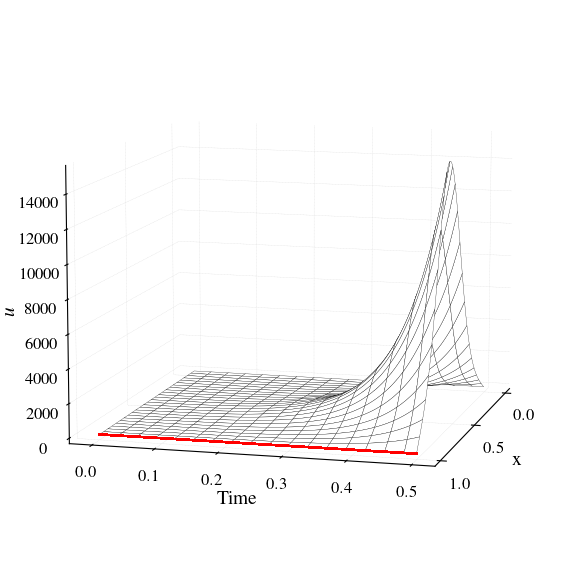

(<Figure size 2120.55x603.753 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='Time', zlabel='$u$'>)

In [52]:
temporal = time_grid

plot_3d_response_draw_style(
    u_data=u_open,
    spatial=spatial,
    temporal=temporal,
    zlabel=r"$u$",
    title=None,
    filename="figs260510/u_open.jpg",
    rstride=30,
    cstride=4,
)

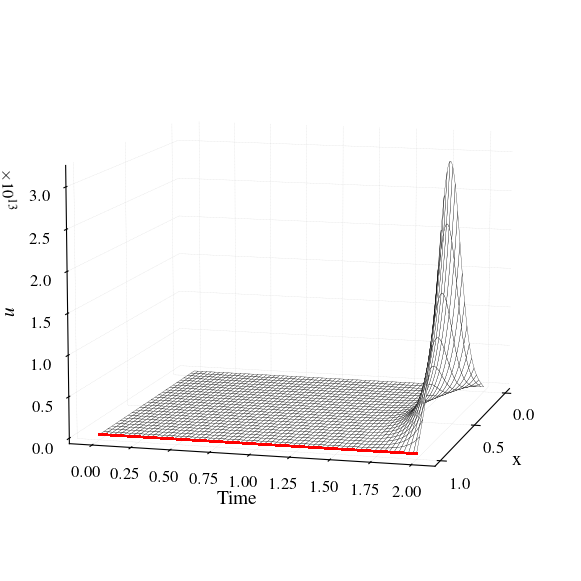

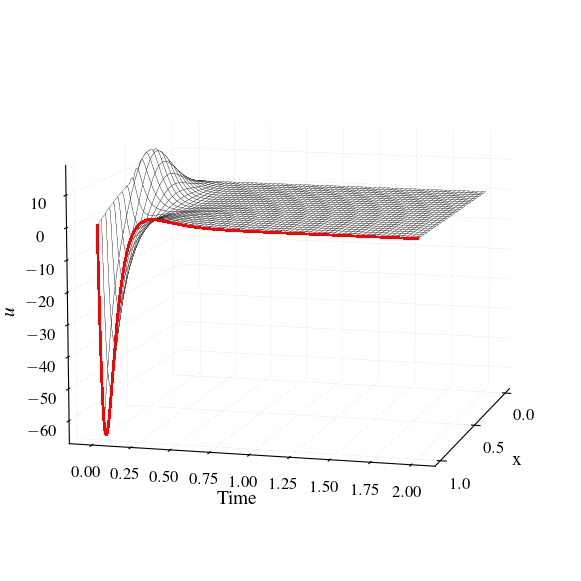

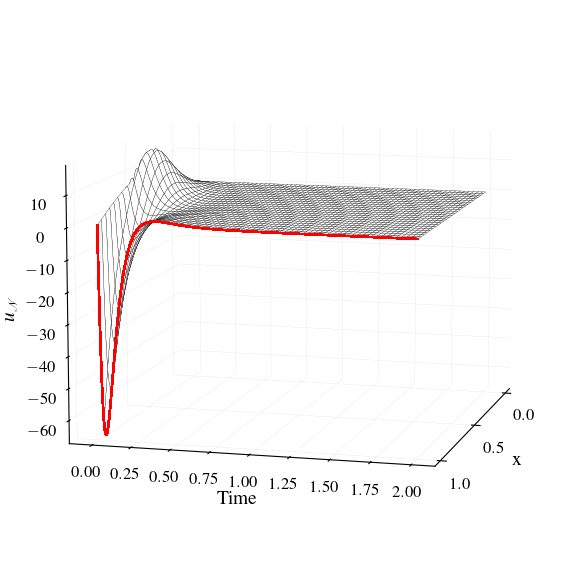

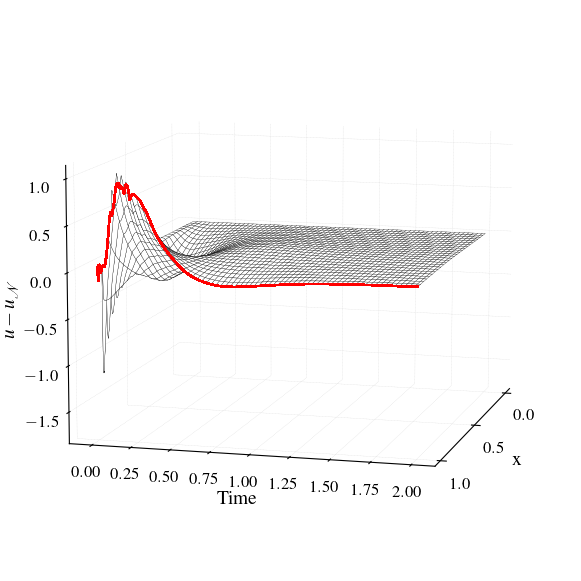

(<Figure size 2120.55x603.753 with 1 Axes>,
 <Axes3D: xlabel='x', ylabel='Time', zlabel='$u-u_{\\mathcal{N}}$'>)

In [50]:
temporal = time_grid

plot_3d_response_draw_style(
    u_data=u_open,
    spatial=spatial,
    temporal=temporal,
    zlabel=r"$u$",
    title=None,
    filename="figs260510/u_open.jpg",
    rstride=30,
    cstride=4,
)

plot_3d_response_draw_style(
    u_data=u_bs,
    spatial=spatial,
    temporal=temporal,
    zlabel=r"$u$",
    title=None,
    filename="figs260510/u_backstepping.jpg",
    rstride=30,
    cstride=4,
)

plot_3d_response_draw_style(
    u_data=u_nn,
    spatial=spatial,
    temporal=temporal,
    zlabel=r"${u}_{\scriptscriptstyle \mathcal{N}}$",
    title=None,
    filename="figs260510/u_nn.jpg",
    rstride=30,
    cstride=4,
)

plot_3d_response_draw_style(
    u_data=u_diff,
    spatial=spatial,
    temporal=temporal,
    zlabel=r"$u-u_{\mathcal{N}}$",
    title=None,
    filename="figs260510/difference_bs_nn.jpg",
    rstride=30,
    cstride=4,
)

In [30]:
simpson_coeff = get_simpson_coeff(spatial)

uL2_open = np.array([
    np.sqrt(simpson_coeff @ (u_open[k, :] ** 2))
    for k in range(len(temporal))
])

uL2_bs = np.array([
    np.sqrt(simpson_coeff @ (u_bs[k, :] ** 2))
    for k in range(len(temporal))
])

uL2_nn = np.array([
    np.sqrt(simpson_coeff @ (u_nn[k, :] ** 2))
    for k in range(len(temporal))
])

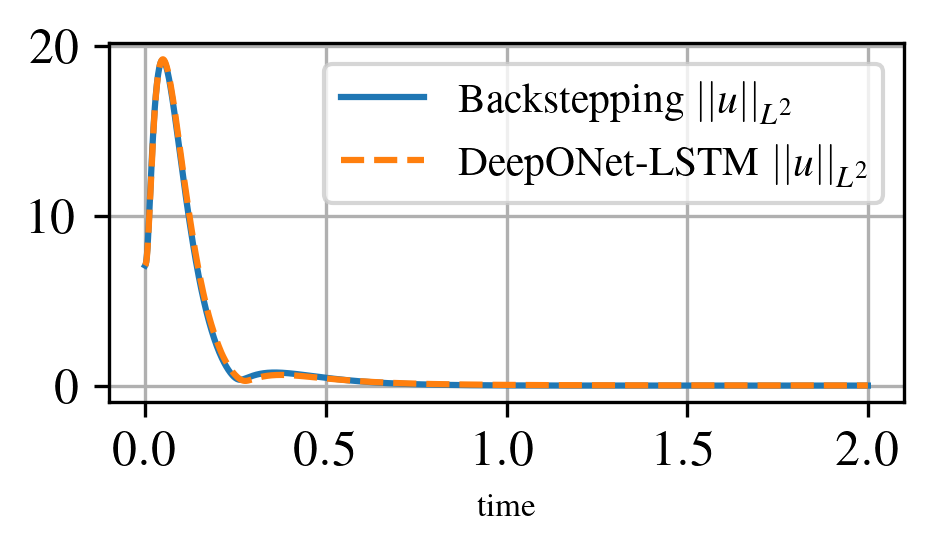

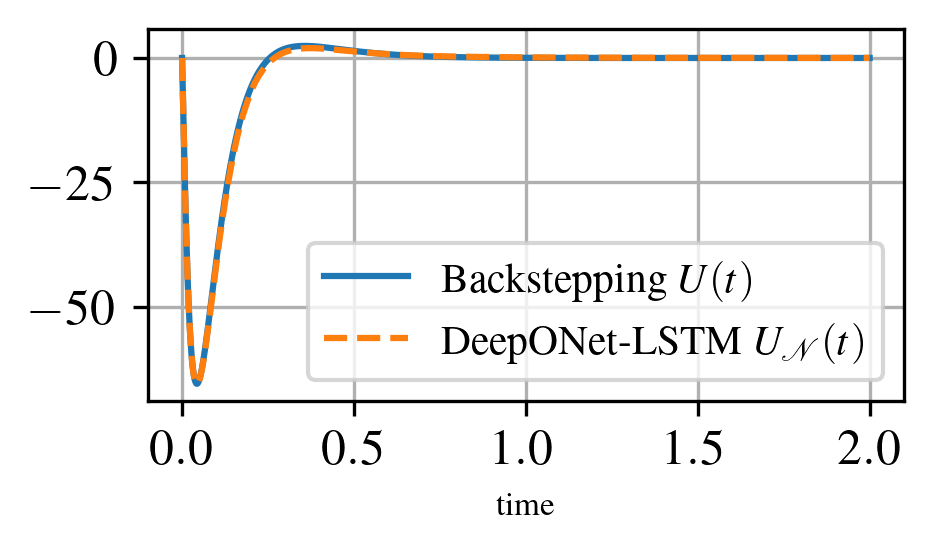

Relative L2 error of control: 0.023588356


In [31]:
plot_2d_draw_style(
    x=temporal,
    ys=[uL2_bs, uL2_nn],
    labels=[
        r"Backstepping $||u||_{L^2}$",
        r"DeepONet-LSTM $||u||_{L^2}$",
    ],
    linestyles=["-", "--"],
    xlabel="time",
    ylabel=None,
    filename="figs260510/comp_L2.jpg",
)

plot_2d_draw_style(
    x=temporal,
    ys=[U_bs, U_nn],
    labels=[
        r"Backstepping $U(t)$",
        r"DeepONet-LSTM $U_{\mathcal{N}}(t)$",
    ],
    linestyles=["-", "--"],
    xlabel="time",
    ylabel=None,
    filename="figs260510/comp_U.jpg",
)

rel_err_U = np.linalg.norm(U_nn - U_bs) / (np.linalg.norm(U_bs) + 1e-12)
print("Relative L2 error of control:", rel_err_U)

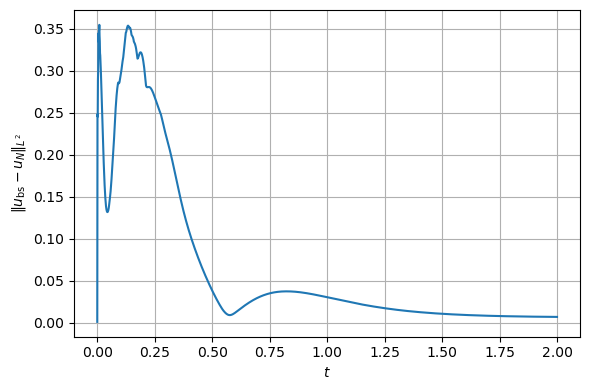

In [141]:
diff_L2 = np.sqrt(np.sum(wq[None, :] * (u_bs - u_nn)**2, axis=1))

plt.figure(figsize=(6, 4))
plt.plot(time_grid, diff_L2)
plt.xlabel(r"$t$")
plt.ylabel(r"$\|u_{\rm bs}-u_N\|_{L^2}$")
plt.grid(True)
plt.tight_layout()
plt.show()